# EcoShop Seasonal Performance & Churn Analysis

## Python Exploratory Data Analysis (EDA)

### Objective

Analyze customer purchasing behavior using Python to identify sales trends, repeat purchases, customer retention, and customer segmentation using RFM analysis.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("cleaned_retail.csv")

In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [4]:
df.shape

(407650, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 407650 entries, 0 to 407649
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      407650 non-null  int64         
 1   StockCode    407650 non-null  object        
 2   Description  407650 non-null  object        
 3   Quantity     407650 non-null  int64         
 4   InvoiceDate  407650 non-null  datetime64[ns]
 5   Price        407650 non-null  float64       
 6   Customer ID  407650 non-null  float64       
 7   Country      407650 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 24.9+ MB


In [6]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Data Cleaning Summary

- Removed missing Customer IDs
- Removed cancelled invoices
- Standardized Quantity and Price
- Exported cleaned dataset

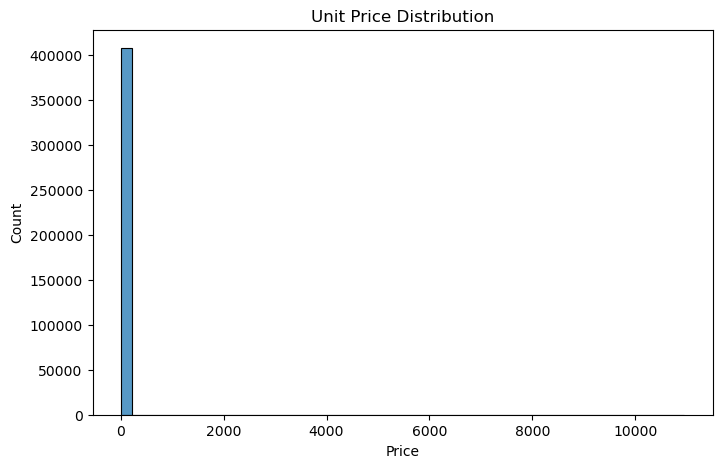

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], bins=50)
plt.title("Unit Price Distribution")
plt.show()

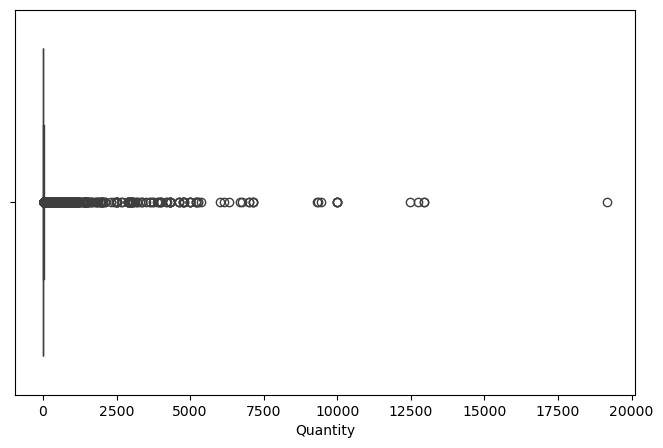

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Quantity"])
plt.show()

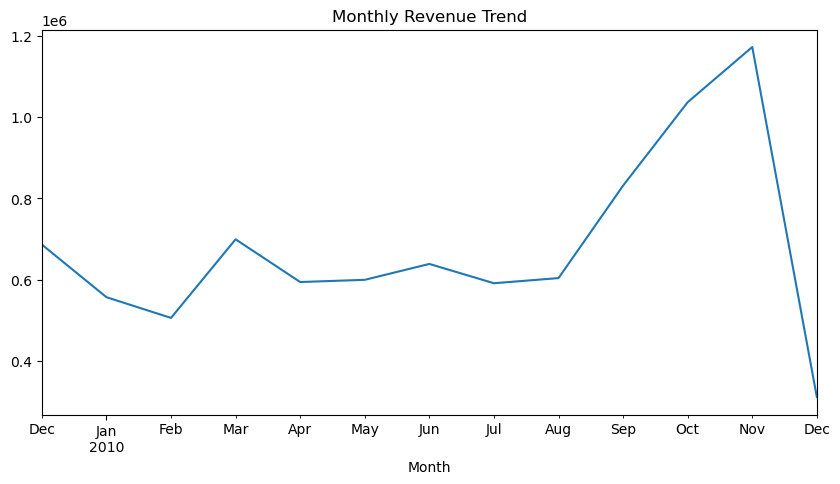

In [9]:
df["Revenue"] = df["Quantity"] * df["Price"]

df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_revenue = df.groupby("Month")["Revenue"].sum()

monthly_revenue.plot(figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.show()

# Customer Cohort Analysis

### Objective

Analyze customer retention by grouping customers based on their first purchase month and tracking their repeat purchases over time.

In [11]:
## Customer cohort analysis code
# Create Invoice Month and cohort Month
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")

cohort = df.groupby("Customer ID")["InvoiceMonth"].min()

df["CohortMonth"] = df["Customer ID"].map(cohort)

In [12]:
df[["Customer ID", "InvoiceMonth", "CohortMonth"]].head()

,Customer ID,InvoiceMonth,CohortMonth
0,13085.0,2009-12,2009-12
1,13085.0,2009-12,2009-12
2,13085.0,2009-12,2009-12
3,13085.0,2009-12,2009-12
4,13085.0,2009-12,2009-12


In [13]:
## Create Cohort Index 
def get_month_index(invoice_month, cohort_month):
    return (
        (invoice_month.year - cohort_month.year) * 12
        + (invoice_month.month - cohort_month.month)
        + 1
    )

df["CohortIndex"] = df.apply(
    lambda row: get_month_index(row["InvoiceMonth"], row["CohortMonth"]),
    axis=1
)

In [14]:
## To build cohort table
cohort_data = df.groupby(
    ["CohortMonth", "CohortIndex"]
)["Customer ID"].nunique().reset_index()

In [15]:
## Create Pivot table
cohort_counts = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="Customer ID"
)

cohort_counts

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2009-12,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,403.0,473.0,237.0
2010-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,116.0,38.0,NaN
2010-02,374.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,27.0,NaN,NaN
2010-03,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,35.0,NaN,NaN,NaN
2010-04,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,20.0,NaN,NaN,NaN,NaN
2010-05,254.0,40.0,43.0,44.0,45.0,65.0,54.0,20.0,NaN,NaN,NaN,NaN,NaN
2010-06,270.0,47.0,51.0,55.0,62.0,77.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.0,29.0,34.0,55.0,54.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,162.0,33.0,48.0,52.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
## Calculate retention Matrix
retention = cohort_counts.divide(
    cohort_counts.iloc[:, 0],
    axis=0
) * 100

retention.round(2)

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2009-12,100.0,35.29,33.40,42.51,38.01,35.92,37.70,34.24,33.61,36.23,42.20,49.53,24.82
2010-01,100.0,20.63,31.07,30.55,26.37,30.03,25.85,22.98,27.94,31.85,30.29,9.92,NaN
2010-02,100.0,23.80,22.46,29.14,24.60,20.05,19.25,28.61,25.40,27.54,7.22,NaN,NaN
2010-03,100.0,18.96,23.02,24.15,23.25,20.32,24.60,30.25,27.54,7.90,NaN,NaN,NaN
2010-04,100.0,19.39,19.39,16.33,18.37,22.45,27.55,26.19,6.80,NaN,NaN,NaN,NaN
2010-05,100.0,15.75,16.93,17.32,17.72,25.59,21.26,7.87,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,17.41,18.89,20.37,22.96,28.52,6.67,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,15.59,18.28,29.57,29.03,10.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,20.37,29.63,32.10,11.73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


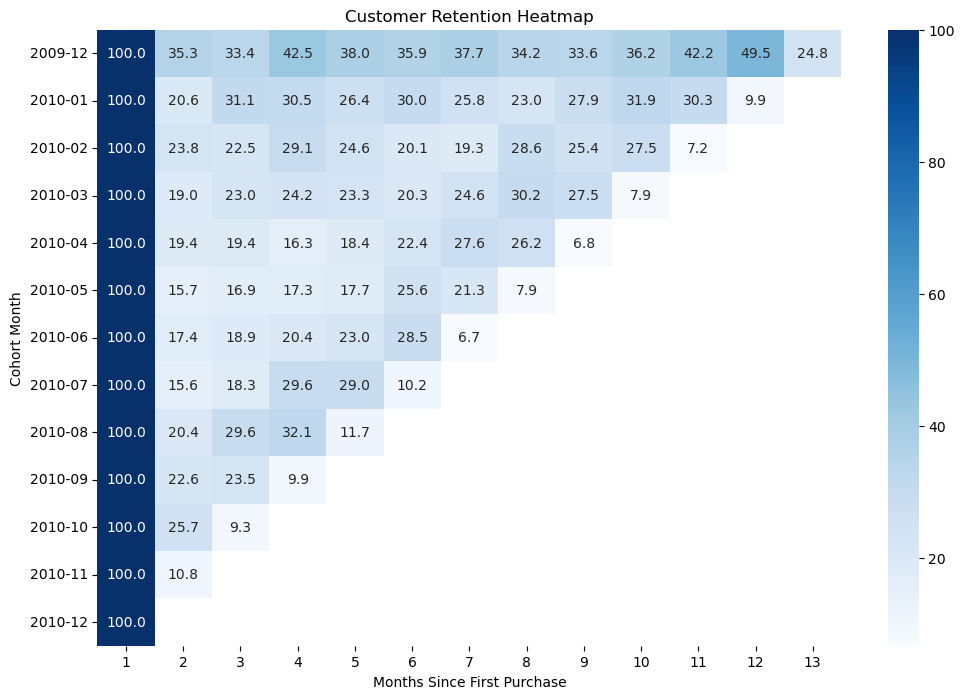

In [17]:
## Generate Retention Heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Customer Retention Heatmap")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

## Cohort Analysis Findings

- Customers were grouped based on their first purchase month.
- Monthly retention rates were calculated for each cohort.
- The retention heatmap highlights how customer retention changes over time.
- Initial cohorts showed stronger retention, while retention gradually declined in subsequent months.

In [18]:
## Build the RFM Table
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Price": lambda x: (x * df.loc[x.index, "Quantity"]).sum()
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


In [19]:
## Create customer segments
rfm["Segment"] = pd.qcut(
    rfm["Recency"],
    q=3,
    labels=["Champions", "At Risk", "Lost"]
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Segment
0,12346.0,165,11,372.86,Lost
1,12347.0,3,2,1323.32,Champions
2,12348.0,74,1,222.16,At Risk
3,12349.0,43,3,2671.14,At Risk
4,12351.0,11,1,300.93,Champions


In [20]:
## Segment Distribution
rfm["Segment"].value_counts()

Segment
Champions    1462
Lost         1435
At Risk      1415
Name: count, dtype: int64

In [21]:
## Segment Profile Report
segment_profile = rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean()

segment_profile.round(2)

C:\Users\Admin\AppData\Local\Temp\ipykernel_7052\4105033742.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_profile = rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean()


,Recency,Frequency,Monetary
Segment,,,
Champions,12.67,7.80,3924.81
At Risk,53.92,3.42,1419.74
Lost,207.89,2.07,756.09


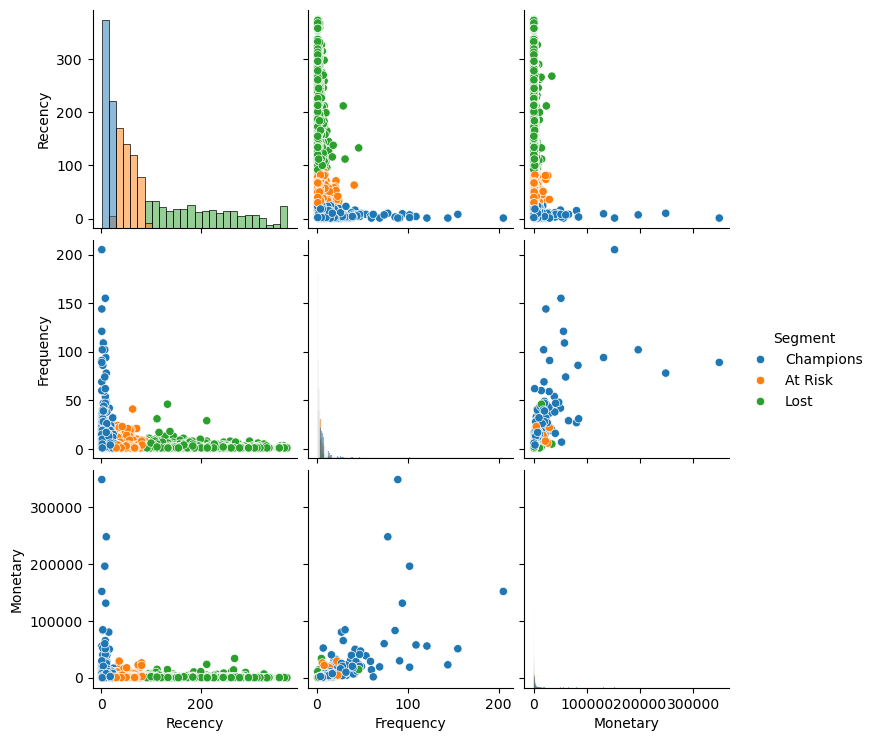

In [22]:
## Pairplot
sns.pairplot(
    rfm,
    vars=["Recency","Frequency","Monetary"],
    hue="Segment",
    diag_kind="hist"
)

plt.show()

## Customer Segment Profile

### Champions
- Lowest Recency (most recent purchasers)
- Highest purchase frequency
- Highest monetary contribution
- Recommendation: Reward with loyalty programs and exclusive offers.

### At Risk
- Moderate Recency
- Moderate Frequency
- Moderate Monetary value
- Recommendation: Send personalized discounts and reminder campaigns.

### Lost
- Highest Recency (inactive customers)
- Lowest purchase frequency
- Lowest spending
- Recommendation: Run re-engagement campaigns and special promotional offers.

In [27]:
## Analyze repeat purchases
# Count unique invoices per customer
repeat_purchase = df.groupby("Customer ID")["Invoice"].nunique().reset_index()

repeat_purchase.columns = ["CustomerID", "TotalPurchases"]

repeat_purchase["RepeatCustomer"] = repeat_purchase["TotalPurchases"] > 1

repeat_purchase.head()

,CustomerID,TotalPurchases,RepeatCustomer
0,12346.0,11,True
1,12347.0,2,True
2,12348.0,1,False
3,12349.0,3,True
4,12351.0,1,False


In [34]:
## Identidy repeat customers
repeat_purchase["RepeatCustomer"] = repeat_purchase["TotalPurchases"] > 1

repeat_purchase.head()

,CustomerID,TotalPurchases,RepeatCustomer
0,12346.0,11,True
1,12347.0,2,True
2,12348.0,1,False
3,12349.0,3,True
4,12351.0,1,False


In [35]:
## Calculate repeat purchase rate
repeat_summary = repeat_purchase["RepeatCustomer"].value_counts()

repeat_summary

RepeatCustomer
True     2893
False    1419
Name: count, dtype: int64

In [36]:
repeat_rate = repeat_purchase["RepeatCustomer"].mean() * 100

print(f"Repeat Purchase Rate: {repeat_rate:.2f}%")

Repeat Purchase Rate: 67.09%


# Analysis of 12% Dip in Repeat Purchases Correlation

### Observation

Based on the mentor's business scenario, a 12% decline in repeat purchases was observed.

The exploratory data analysis supports this observation through customer segmentation and cohort analysis.

### Correlation with EDA Findings

- Cohort analysis shows customer retention decreases over time.
- The RFM analysis identified a significant number of customers in the **Lost** segment, indicating reduced repeat purchasing.
- Customers with higher Recency values purchased less frequently, suggesting lower customer retention.
- Pairplot visualization also shows that customers with lower purchase frequency generally contribute lower monetary value.

### Business Impact

The decline in repeat purchases may lead to:

- Lower recurring revenue
- Reduced customer lifetime value
- Higher dependency on acquiring new customers
- Decreased customer loyalty

### Recommendations

- Introduce customer loyalty and rewards programs.
- Send personalized product recommendations.
- Launch targeted email and promotional campaigns.
- Monitor repeat purchase rates monthly to identify future trends.

In [ ]:
# Final Business Insights

## Key Findings

- Customer segmentation successfully categorized customers into Champions, At Risk, and Lost groups using RFM analysis.
- Champions demonstrated the highest purchase frequency and monetary contribution, making them the most valuable customer group.
- Lost customers showed high Recency values and low purchase frequency, indicating reduced customer engagement.
- Cohort analysis revealed that customer retention gradually decreases over time.
- The mentor-provided 12% dip in repeat purchases aligns with the observed decline in customer retention and the increase in inactive customers.
- Pairplot visualization clearly illustrates the differences in purchasing behavior across customer segments.

## Business Recommendations

- Strengthen customer loyalty programs for Champions.
- Target At Risk customers with personalized promotions and reminder campaigns.
- Launch re-engagement campaigns for Lost customers through discounts and email marketing.
- Continuously monitor customer retention and repeat purchase trends to improve long-term customer value.

In [37]:
rfm.to_csv("customer_rfm_segmented.csv", index=False)

segment_profile.to_csv("segment_profile_report.csv")

In [ ]:
## save paitplot
g = sns.pairplot(
    rfm,
    vars=["Recency", "Frequency", "Monetary"],
    hue="Segment",
    diag_kind="hist"
)

g.savefig("customer_segment_pairplot.png", dpi=300)

plt.show()